In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Arc
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import cm

In [42]:
# pattern = '/Volumes/Untitled/hic_files/results/2021-09-10-HiC-HU.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2021-09-10-Rep-HiC-HU.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2023-11-04-HiC-HU.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2023-11-04-Rep-HiC-HU_rerun.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2023-11-04-Rep-HiC-HU_rerun.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2024-02-16-HiC-HU-MRC5-WT.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2024-02-and-04-Rep-HiC-HU-MRC5-WT-merged-rerun.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2024-02-and-04-Rep-HiC-HU-MRC5-G9ai-merged.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
pattern = "/Volumes/Untitled/results/2025-Hi-c-G9ai/sub_compartments/all_sub_compartments.tsv"

df_hu = pd.read_csv(pattern, sep='\t').iloc[:, :6]
df_hu['comp_name'] = df_hu['comp_name'].str[:5]
df_hu

# pattern = '/Volumes/Untitled/hic_files/results/2021-09-10-HiC-NT.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2021-09-10-Rep-HiC-NT.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2023-11-04-HiC-NT.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2023-11-04-Rep-HiC-NT_rerun.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
pattern = '/Volumes/Untitled/hic_files/results/2024-02-16-HiC-NT-MRC5-WT.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'
# pattern = '/Volumes/Untitled/hic_files/results/2024-02-and-04-Rep-HiC-UT-MRC5-WT-merged-rerun.merged_sort.MAPQ.30/sub_compartments/all_sub_compartments.tsv'

# concatenate all chromosomes into one DataFrame
df_ut = pd.read_csv(pattern, sep='\t').iloc[:, :6]
df_ut['comp_name'] = df_ut['comp_name'].str[:5]
df_ut


df = (df_ut[['chr', 'pos_start', 'pos_end', 'comp_name', 'comp_rank', 'continous_rank']].merge(
    df_hu[['chr', 'pos_start', 'pos_end', 'comp_name', 'comp_rank', 'continous_rank']], 
    on=['chr', 'pos_start', 'pos_end'], suffixes=('_ut', '_hu')))
df

,chr,pos_start,pos_end,comp_name_ut,comp_rank_ut,continous_rank_ut,comp_name_hu,comp_rank_hu,continous_rank_hu
0,chr1,600001,610000.0,A.1.2,0.875,0.866268,A.1.1,1.0,0.921340
1,chr1,610001,620000.0,A.1.2,0.875,0.866268,A.1.1,1.0,0.921340
2,chr1,620001,630000.0,A.1.2,0.875,0.866268,A.1.1,1.0,0.921340
3,chr1,630001,640000.0,A.1.2,0.875,0.866268,A.1.1,1.0,0.921340
4,chr1,640001,650000.0,A.1.2,0.875,0.866268,A.1.1,1.0,0.921340
...,...,...,...,...,...,...,...,...,...
260065,chr22,50750001,50760000.0,A.1.1,1.000,0.906612,A.1.1,1.0,0.971573
260066,chr22,50760001,50770000.0,A.1.1,1.000,0.906612,A.1.1,1.0,0.971573
260067,chr22,50770001,50780000.0,A.1.1,1.000,0.906612,A.1.1,1.0,0.971573
260068,chr22,50780001,50790000.0,A.1.1,1.000,0.906612,A.1.1,1.0,0.971573


Total bins: 260070
Any shift (UT→HU): 114885 bins (44.2%)
Sub‐compartment reposition within A/B: 98190 bins (37.8%)
A → B transitions (UT→HU): 8470 bins (3.3%)
Downward shifts (toward B-like): 55495 bins (21.3%)


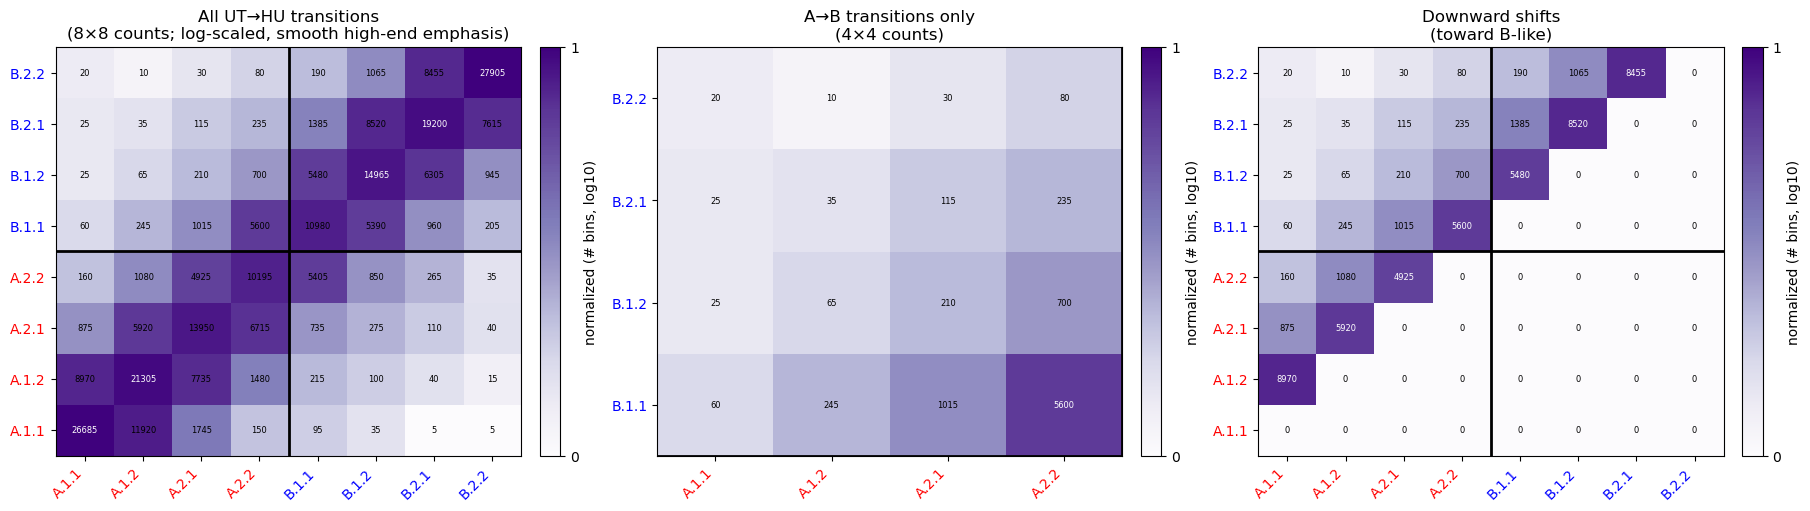

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =========================
# Params for the colorscale
# (same smooth, high-end–emphasized gradient as earlier, on log10 data)
t1_lin, t2_lin = 1_000.0, 7_000.0      # thresholds in *linear* counts
pct_low, pct_mid, pct_high = 55, 30, 15  # % of colormap for <t1, t1–t2, >t2
# =========================

# 1) Ordered sub-compartments (most active → most repressive)
all_subs = ['A.1.1','A.1.2','A.2.1','A.2.2','B.1.1','B.1.2','B.2.1','B.2.2']

# 2) Hierarchy (higher index → more repressive)
hierarchy = {sub: i for i, sub in enumerate(all_subs)}

# 3) Broad A/B definitions
df['broad_ut'] = df['comp_name_ut'].str.split('.').str[0]
df['broad_hu'] = df['comp_name_hu'].str.split('.').str[0]

# 4) Totals & masks
total_bins = len(df)
mask_any_shift = df['comp_name_ut'] != df['comp_name_hu']
mask_same_AB   = (df['broad_ut'] == df['broad_hu']) & mask_any_shift
mask_A2B       = (df['broad_ut'] == 'A') & (df['broad_hu'] == 'B')
mask_downward  = df['comp_name_ut'].map(hierarchy) < df['comp_name_hu'].map(hierarchy)

# 5) Counts & percentages
n_any      = mask_any_shift.sum()
n_repos    = mask_same_AB.sum()
n_A2B      = mask_A2B.sum()
n_downward = mask_downward.sum()

pct_any      = n_any      / total_bins * 100
pct_repos    = n_repos    / total_bins * 100
pct_A2B      = n_A2B      / total_bins * 100
pct_downward = n_downward / total_bins * 100

print(f"Total bins: {total_bins}")
print(f"Any shift (UT→HU): {n_any} bins ({pct_any:.1f}%)")
print(f"Sub‐compartment reposition within A/B: {n_repos} bins ({pct_repos:.1f}%)")
print(f"A → B transitions (UT→HU): {n_A2B} bins ({pct_A2B:.1f}%)")
print(f"Downward shifts (toward B-like): {n_downward} bins ({pct_downward:.1f}%)")

# 6) Pivots
pivot_all = (
    df.pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=all_subs, columns=all_subs, fill_value=0)
)

subs_ut_A = [s for s in all_subs if s.startswith('A.')]
subs_hu_B = [s for s in all_subs if s.startswith('B.')]
pivot_A2B = (
    df.loc[mask_A2B]
      .pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=subs_hu_B, columns=subs_ut_A, fill_value=0)
)

pivot_down = (
    df.loc[mask_downward]
      .pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=all_subs, columns=all_subs, fill_value=0)
)

# ---------- Shared log scaling & piecewise gradient (as earlier) ----------
# Use the *global* range from the full 8×8 to normalize all panels consistently.
vals_all_log = np.log10(pivot_all.values.astype(float) + 1.0)
vmin_log = float(vals_all_log.min())
vmax_log = float(vals_all_log.max())
den = (vmax_log - vmin_log) if (vmax_log > vmin_log) else 1.0

# Thresholds in normalized (log) space, shared across panels
t1_norm = float(np.clip((np.log10(t1_lin + 1.0) - vmin_log) / den, 0, 1))
t2_norm = float(np.clip((np.log10(t2_lin + 1.0) - vmin_log) / den, 0, 1))
if not (t1_norm < t2_norm):  # guard if thresholds collapse
    t2_norm = min(1.0, t1_norm + 1e-6)

# Colormap allocation per region (<t1, t1–t2, >t2) — smooth, not binned
p = np.array([pct_low, pct_mid, pct_high], dtype=float)
p = p / (p.sum() if p.sum() > 0 else 1.0)
y_breaks = np.r_[0.0, p[0], p[0] + p[1], 1.0]  # e.g., [0, 0.55, 0.85, 1]

class PiecewiseLinearNorm(mcolors.Normalize):
    """Expect input in [0,1]; allocate extra colormap space to high-end smoothly."""
    def __init__(self, x, y, clip=False):
        super().__init__(vmin=0.0, vmax=1.0, clip=clip)
        self.x = np.asarray(x, dtype=float)
        self.y = np.asarray(y, dtype=float)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value, dtype=float)
        out = np.interp(v, self.x, self.y)
        return np.ma.masked_array(out, np.ma.getmask(v))

shared_norm = PiecewiseLinearNorm(x=[0.0, t1_norm, t2_norm, 1.0], y=y_breaks, clip=True)
cmap = 'Purples'

def to_norm01(data_vals):
    """log10 transform then normalize to [0,1] using shared vmin/vmax."""
    v = np.log10(data_vals.astype(float) + 1.0)
    return (v - vmin_log) / den

# ---------- Plotting ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

def draw_heatmap(ax, data, title):
    vals01 = to_norm01(data.values)
    im = ax.imshow(vals01, aspect='auto', cmap=cmap, norm=shared_norm, origin='lower')
    ax.set_title(title)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    # color A/B labels
    for lbl in ax.get_xticklabels():
        lbl.set_color('red' if lbl.get_text().startswith('A.') else 'blue')
    for lbl in ax.get_yticklabels():
        lbl.set_color('red' if lbl.get_text().startswith('A.') else 'blue')
    # quadrant lines
    ax.axvline(sum(s.startswith('A.') for s in data.columns) - 0.5, color='black', lw=2)
    ax.axhline(sum(s.startswith('A.') for s in data.index)   - 0.5, color='black', lw=2)
    # annotate raw counts (use raw data for thresholding text color)
    th = data.values.max() / 2.0 if data.values.size else 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            c = data.iat[i, j]
            ax.text(j, i, str(int(c)), ha='center', va='center',
                    color=('white' if c > th else 'black'), fontsize=6)
    return im

im0 = draw_heatmap(axes[0], pivot_all, 'All UT→HU transitions\n(8×8 counts; log-scaled, smooth high-end emphasis)')
im1 = draw_heatmap(axes[1], pivot_A2B, 'A→B transitions only\n(4×4 counts)')
im2 = draw_heatmap(axes[2], pivot_down, 'Downward shifts\n(toward B-like)')

# Colorbars (consistent ticks across panels)
for ax in axes:
    cb = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04,
                      label='normalized (# bins, log10)')
    cb.set_ticks([0.0, 1.0])
    # cb.set_ticklabels(['0', f'≈{int(t1_lin):,}', f'≈{int(t2_lin):,}', '1'])

plt.show()


Total bins: 260070
Any shift (UT→HU): 114885 bins (44.2%)
Sub‐compartment reposition within A/B: 98190 bins (37.8%)
A → B transitions (UT→HU): 8470 bins (3.3%)
Downward shifts (toward B-like): 55495 bins (21.3%)
No change (UT=HU): 145185 bins (55.8%)


/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_96244/707956924.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap("Purples").copy()


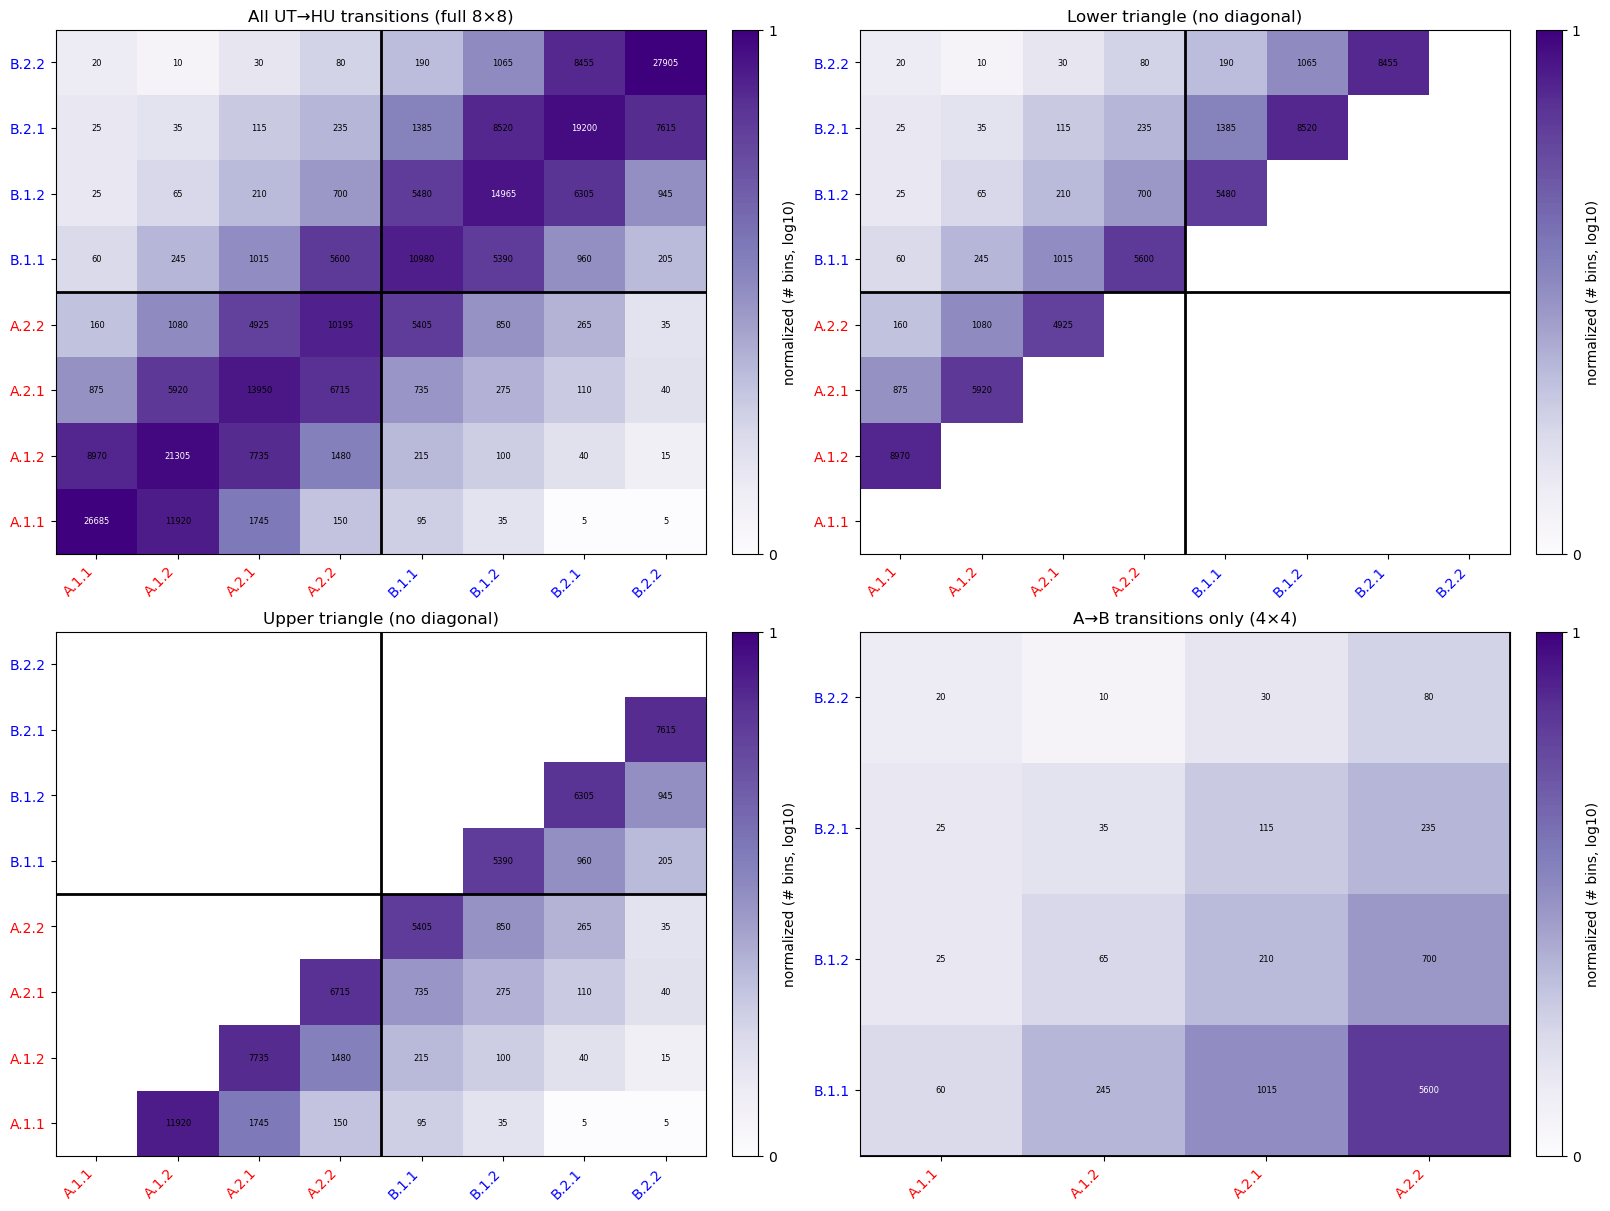

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =========================
# Params for the colorscale
t1_lin, t2_lin = 1_000.0, 7_000.0
pct_low, pct_mid, pct_high = 55, 30, 15
# =========================

# 1) Ordered sub-compartments (most active → most repressive)
all_subs = ['A.1.1','A.1.2','A.2.1','A.2.2',
            'B.1.1','B.1.2','B.2.1','B.2.2']

hierarchy = {sub: i for i, sub in enumerate(all_subs)}

# 2) Broad A/B definitions
df['broad_ut'] = df['comp_name_ut'].str.split('.').str[0]
df['broad_hu'] = df['comp_name_hu'].str.split('.').str[0]

# 3) Totals & masks
total_bins = len(df)
mask_any_shift = df['comp_name_ut'] != df['comp_name_hu']
mask_same_AB   = (df['broad_ut'] == df['broad_hu']) & mask_any_shift
mask_A2B       = (df['broad_ut'] == 'A') & (df['broad_hu'] == 'B')
mask_downward  = df['comp_name_ut'].map(hierarchy) < df['comp_name_hu'].map(hierarchy)

# 4) Counts & percentages
n_any      = mask_any_shift.sum()
n_repos    = mask_same_AB.sum()
n_A2B      = mask_A2B.sum()
n_downward = mask_downward.sum()
n_same     = (df['comp_name_ut'] == df['comp_name_hu']).sum()  # unchanged bins

pct_any      = n_any      / total_bins * 100
pct_repos    = n_repos    / total_bins * 100
pct_A2B      = n_A2B      / total_bins * 100
pct_downward = n_downward / total_bins * 100
pct_same     = n_same     / total_bins * 100

print(f"Total bins: {total_bins}")
print(f"Any shift (UT→HU): {n_any} bins ({pct_any:.1f}%)")
print(f"Sub‐compartment reposition within A/B: {n_repos} bins ({pct_repos:.1f}%)")
print(f"A → B transitions (UT→HU): {n_A2B} bins ({pct_A2B:.1f}%)")
print(f"Downward shifts (toward B-like): {n_downward} bins ({pct_downward:.1f}%)")
print(f"No change (UT=HU): {n_same} bins ({pct_same:.1f}%)")

# 5) Pivots
pivot_all = (
    df.pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=all_subs, columns=all_subs, fill_value=0)
)

subs_ut_A = [s for s in all_subs if s.startswith('A.')]
subs_hu_B = [s for s in all_subs if s.startswith('B.')]
pivot_A2B = (
    df.loc[mask_A2B]
      .pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=subs_hu_B, columns=subs_ut_A, fill_value=0)
)

# ---------- Shared log scaling & piecewise gradient ----------
vals_all_log = np.log10(pivot_all.values.astype(float) + 1.0)
vmin_log = float(vals_all_log.min())
vmax_log = float(vals_all_log.max())
den = (vmax_log - vmin_log) if (vmax_log > vmin_log) else 1.0

t1_norm = float(np.clip((np.log10(t1_lin + 1.0) - vmin_log) / den, 0, 1))
t2_norm = float(np.clip((np.log10(t2_lin + 1.0) - vmin_log) / den, 0, 1))
if not (t1_norm < t2_norm):
    t2_norm = min(1.0, t1_norm + 1e-6)

p = np.array([pct_low, pct_mid, pct_high], dtype=float)
p = p / (p.sum() if p.sum() > 0 else 1.0)
y_breaks = np.r_[0.0, p[0], p[0] + p[1], 1.0]

class PiecewiseLinearNorm(mcolors.Normalize):
    def __init__(self, x, y, clip=False):
        super().__init__(vmin=0.0, vmax=1.0, clip=clip)
        self.x = np.asarray(x, dtype=float)
        self.y = np.asarray(y, dtype=float)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value, dtype=float)
        out = np.interp(v, self.x, self.y)
        return np.ma.masked_array(out, np.ma.getmask(v))

shared_norm = PiecewiseLinearNorm(x=[0.0, t1_norm, t2_norm, 1.0], y=y_breaks, clip=True)

cmap_obj = plt.cm.get_cmap("Purples").copy()
cmap_obj.set_bad(alpha=0)

def to_norm01(data_vals):
    v = np.log10(data_vals.astype(float) + 1.0)
    return (v - vmin_log) / den

# --- Mask helpers ---
def get_triangle_mask(shape, triangle='full'):
    nrows, ncols = shape
    mask = np.zeros((nrows, ncols), dtype=bool)
    if nrows == ncols:
        if triangle == 'upper':
            mask = np.tril(np.ones((nrows, ncols), dtype=bool), k=0)  # remove diagonal too
        elif triangle == 'lower':
            mask = np.triu(np.ones((nrows, ncols), dtype=bool), k=0)  # remove diagonal too
    return mask

def draw_heatmap(ax, data, title, triangle='full'):
    mask = get_triangle_mask(data.shape, triangle)
    vals01 = to_norm01(data.values.astype(float))
    vals01_masked = np.ma.masked_array(vals01, mask=mask)

    im = ax.imshow(vals01_masked, aspect='auto', cmap=cmap_obj,
                   norm=shared_norm, origin='lower')
    ax.set_title(title)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)

    for lbl in ax.get_xticklabels():
        lbl.set_color('red' if lbl.get_text().startswith('A.') else 'blue')
    for lbl in ax.get_yticklabels():
        lbl.set_color('red' if lbl.get_text().startswith('A.') else 'blue')

    ax.axvline(sum(s.startswith('A.') for s in data.columns) - 0.5, color='black', lw=2)
    ax.axhline(sum(s.startswith('A.') for s in data.index)   - 0.5, color='black', lw=2)

    th = data.values.max() / 2.0 if data.values.size else 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if mask[i, j]:
                continue
            c = data.iat[i, j]
            ax.text(j, i, str(int(c)), ha='center', va='center',
                    color=('white' if c > th else 'black'), fontsize=6)
    return im

# ---------- PLOTTING ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

draw_heatmap(axes[0, 0], pivot_all,
             'All UT→HU transitions (full 8×8)', triangle='full')
draw_heatmap(axes[0, 1], pivot_all,
             'Lower triangle (no diagonal)', triangle='lower')
draw_heatmap(axes[1, 0], pivot_all,
             'Upper triangle (no diagonal)', triangle='upper')
draw_heatmap(axes[1, 1], pivot_A2B,
             'A→B transitions only (4×4)', triangle='full')

# Colorbars
for ax_row in axes:
    for ax in ax_row:
        cb = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04,
                          label='normalized (# bins, log10)')
        cb.set_ticks([0.0, 1.0])

plt.show()


Total bins: 260070
No change (UT=HU): 145185 bins (55.8%)
Any shift (UT→HU): 114885 bins (44.2%)
Sub-compartment reposition within same A/B: 98190 bins (37.8%)
A → B transitions (broad): 8470 bins (3.3%)
B → A transitions (broad): 8225 bins (3.2%)
Downward shifts (toward B-like): 55495 bins (21.3%)
Upward shifts (toward A-like): 59390 bins (22.8%)


/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_96244/2753910214.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap("Purples").copy()


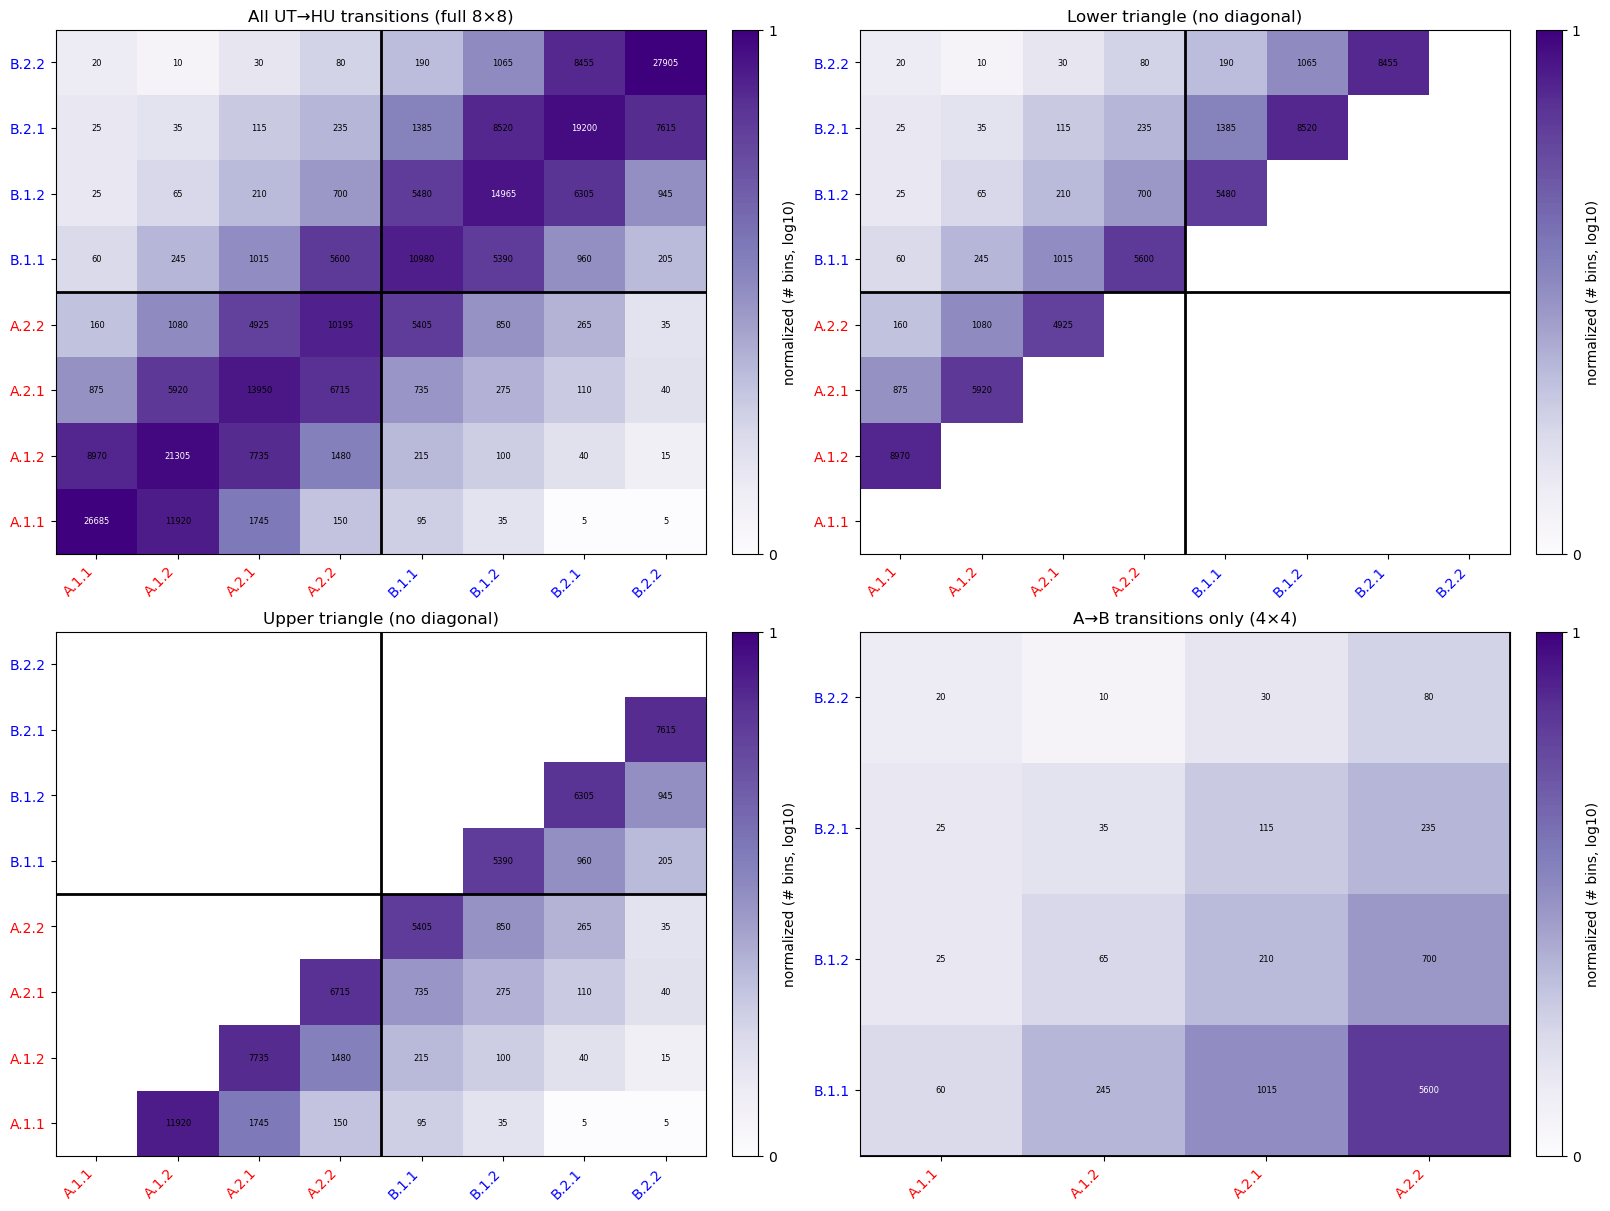

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =========================
# Params for the colorscale
t1_lin, t2_lin = 1_000.0, 7_000.0
pct_low, pct_mid, pct_high = 55, 30, 15
# =========================

# 1) Ordered sub-compartments (most active → most repressive)
all_subs = ['A.1.1','A.1.2','A.2.1','A.2.2',
            'B.1.1','B.1.2','B.2.1','B.2.2']

hierarchy = {sub: i for i, sub in enumerate(all_subs)}  # higher idx → more repressive

# 2) Broad A/B definitions
df['broad_ut'] = df['comp_name_ut'].str.split('.').str[0]
df['broad_hu'] = df['comp_name_hu'].str.split('.').str[0]

# 3) Totals & masks
total_bins   = len(df)
mask_any     = df['comp_name_ut'] != df['comp_name_hu']
mask_sameAB  = (df['broad_ut'] == df['broad_hu']) & mask_any
mask_A2B     = (df['broad_ut'] == 'A') & (df['broad_hu'] == 'B')
mask_B2A     = (df['broad_ut'] == 'B') & (df['broad_hu'] == 'A')  # NEW
# "Downward" (toward B-like) = more repressive after HU
mask_down    = df['comp_name_ut'].map(hierarchy) < df['comp_name_hu'].map(hierarchy)
# "Upward" (toward A-like) = less repressive after HU  (NEW)
mask_up      = df['comp_name_ut'].map(hierarchy) > df['comp_name_hu'].map(hierarchy)

# 4) Counts & percentages
n_any   = mask_any.sum()
n_same  = (df['comp_name_ut'] == df['comp_name_hu']).sum()
n_repos = mask_sameAB.sum()
n_A2B   = mask_A2B.sum()
n_B2A   = mask_B2A.sum()      # NEW
n_down  = mask_down.sum()
n_up    = mask_up.sum()       # NEW

pct_any   = n_any   / total_bins * 100
pct_same  = n_same  / total_bins * 100
pct_repos = n_repos / total_bins * 100
pct_A2B   = n_A2B   / total_bins * 100
pct_B2A   = n_B2A   / total_bins * 100  # NEW
pct_down  = n_down  / total_bins * 100
pct_up    = n_up    / total_bins * 100  # NEW

print(f"Total bins: {total_bins}")
print(f"No change (UT=HU): {n_same} bins ({pct_same:.1f}%)")
print(f"Any shift (UT→HU): {n_any} bins ({pct_any:.1f}%)")
print(f"Sub-compartment reposition within same A/B: {n_repos} bins ({pct_repos:.1f}%)")
print(f"A → B transitions (broad): {n_A2B} bins ({pct_A2B:.1f}%)")
print(f"B → A transitions (broad): {n_B2A} bins ({pct_B2A:.1f}%)")          # NEW
print(f"Downward shifts (toward B-like): {n_down} bins ({pct_down:.1f}%)")
print(f"Upward shifts (toward A-like): {n_up} bins ({pct_up:.1f}%)")        # NEW

# 5) Pivots
pivot_all = (
    df.pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=all_subs, columns=all_subs, fill_value=0)
)

subs_ut_A = [s for s in all_subs if s.startswith('A.')]
subs_hu_B = [s for s in all_subs if s.startswith('B.')]
pivot_A2B = (
    df.loc[mask_A2B]
      .pivot_table(index='comp_name_hu', columns='comp_name_ut', values='chr',
                   aggfunc='count', fill_value=0)
      .reindex(index=subs_hu_B, columns=subs_ut_A, fill_value=0)
)

# ---------- Shared log scaling & piecewise gradient ----------
vals_all_log = np.log10(pivot_all.values.astype(float) + 1.0)
vmin_log = float(vals_all_log.min())
vmax_log = float(vals_all_log.max())
den = (vmax_log - vmin_log) if (vmax_log > vmin_log) else 1.0

t1_norm = float(np.clip((np.log10(t1_lin + 1.0) - vmin_log) / den, 0, 1))
t2_norm = float(np.clip((np.log10(t2_lin + 1.0) - vmin_log) / den, 0, 1))
if not (t1_norm < t2_norm):
    t2_norm = min(1.0, t1_norm + 1e-6)

p = np.array([pct_low, pct_mid, pct_high], dtype=float)
p = p / (p.sum() if p.sum() > 0 else 1.0)
y_breaks = np.r_[0.0, p[0], p[0] + p[1], 1.0]

class PiecewiseLinearNorm(mcolors.Normalize):
    def __init__(self, x, y, clip=False):
        super().__init__(vmin=0.0, vmax=1.0, clip=clip)
        self.x = np.asarray(x, dtype=float)
        self.y = np.asarray(y, dtype=float)
    def __call__(self, value, clip=None):
        v = np.ma.asarray(value, dtype=float)
        out = np.interp(v, self.x, self.y)
        return np.ma.masked_array(out, np.ma.getmask(v))

shared_norm = PiecewiseLinearNorm(x=[0.0, t1_norm, t2_norm, 1.0], y=y_breaks, clip=True)

cmap_obj = plt.cm.get_cmap("Purples").copy()
cmap_obj.set_bad(alpha=0)

def to_norm01(data_vals):
    v = np.log10(data_vals.astype(float) + 1.0)
    return (v - vmin_log) / den

# --- Mask helpers (plotting-only; values unchanged) ---
def get_triangle_mask(shape, triangle='full'):
    nrows, ncols = shape
    mask = np.zeros((nrows, ncols), dtype=bool)
    if nrows == ncols:
        if triangle == 'upper':
            mask = np.tril(np.ones((nrows, ncols), dtype=bool), k=0)  # hide diag+lower
        elif triangle == 'lower':
            mask = np.triu(np.ones((nrows, ncols), dtype=bool), k=0)  # hide diag+upper
    return mask

def draw_heatmap(ax, data, title, triangle='full'):
    mask = get_triangle_mask(data.shape, triangle)
    vals01 = to_norm01(data.values.astype(float))
    vals01_masked = np.ma.masked_array(vals01, mask=mask)

    im = ax.imshow(vals01_masked, aspect='auto', cmap=cmap_obj,
                   norm=shared_norm, origin='lower')
    ax.set_title(title)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)

    # color A/B labels
    for lbl in ax.get_xticklabels():
        lbl.set_color('red' if lbl.get_text().startswith('A.') else 'blue')
    for lbl in ax.get_yticklabels():
        lbl.set_color('red' if lbl.get_text().startswith('A.') else 'blue')

    # quadrant split lines
    ax.axvline(sum(s.startswith('A.') for s in data.columns) - 0.5, color='black', lw=2)
    ax.axhline(sum(s.startswith('A.') for s in data.index)   - 0.5, color='black', lw=2)

    # annotate raw counts (skip masked cells)
    th = data.values.max() / 2.0 if data.values.size else 0
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if mask[i, j]:
                continue
            c = data.iat[i, j]
            ax.text(j, i, str(int(c)), ha='center', va='center',
                    color=('white' if c > th else 'black'), fontsize=6)
    return im

# ---------- PLOTTING ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

draw_heatmap(axes[0, 0], pivot_all,
             'All UT→HU transitions (full 8×8)', triangle='full')
draw_heatmap(axes[0, 1], pivot_all,
             'Lower triangle (no diagonal)', triangle='lower')
draw_heatmap(axes[1, 0], pivot_all,
             'Upper triangle (no diagonal)', triangle='upper')
draw_heatmap(axes[1, 1], pivot_A2B,
             'A→B transitions only (4×4)', triangle='full')

# Colorbars
for ax_row in axes:
    for ax in ax_row:
        cb = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04,
                          label='normalized (# bins, log10)')
        cb.set_ticks([0.0, 1.0])

plt.show()
